<a href="https://colab.research.google.com/github/Abisu9/NLP/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Read CSV file
df = pd.read_csv("spam.csv", encoding='latin1')

# Rename columns and drop unnecessary ones
df = df.rename(columns={'v1':'label', 'v2':'text'})
df = df[['label','text']]

print(df.head())
print(df["label"].value_counts())

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
print(df[['text','clean_text']])

                                                   text  \
0     Go until jurong point, crazy.. Available only ...   
1                         Ok lar... Joking wif u oni...   
2     Free entry in 2 a wkly comp to win FA Cup fina...   
3     U dun say so early hor... U c already then say...   
4     Nah I don't think he goes to usf, he lives aro...   
...                                                 ...   
5567  This is the 2nd time we have tried 2 contact u...   
5568              Will Ì_ b going to esplanade fr home?   
5569  Pity, * was in mood for that. So...any other s...   
5570  The guy did some bitching but I acted like i'd...   
5571                         Rofl. Its true to its name   

                                             clean_text  
0     go until jurong point crazy available only in ...  
1                               ok lar joking wif u oni  
2     free entry in a wkly comp to win fa cup final ...  
3           u dun say so early hor u c already then say  
4

In [ ]:
# Train-Test split
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 3900
Testing samples: 1672


In [ ]:
 #Convert Text to Numerical Features (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Feature names:", vectorizer.get_feature_names_out())
print("Training TF-IDF shape:", X_train_tfidf.shape)

Feature names: ['aa' 'aah' 'aaooooright' ... 'zoom' 'zouk' 'zs']
Training TF-IDF shape: (3900, 6970)


In [ ]:
#Build a Naïve Bayes Classifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Naïve Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

Naïve Bayes Accuracy: 0.9503588516746412
Classification Report:
               precision    recall  f1-score   support

         ham       0.95      1.00      0.97      1453
        spam       1.00      0.62      0.77       219

    accuracy                           0.95      1672
   macro avg       0.97      0.81      0.87      1672
weighted avg       0.95      0.95      0.95      1672



In [ ]:
#Build a Support Vector Machine (SVM) Classifier
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.9814593301435407
Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99      1453
        spam       0.99      0.87      0.92       219

    accuracy                           0.98      1672
   macro avg       0.98      0.93      0.96      1672
weighted avg       0.98      0.98      0.98      1672



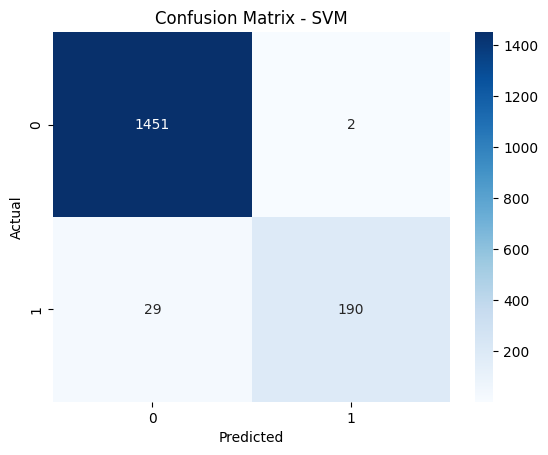

In [ ]:
#Confusion Matrix Visualization (Optional)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
#Predict on New Text Samples
samples = [
    "Win a brand new car by clicking this link",
    "Can we meet for class tomorrow?",
]

clean_samples = [clean_text(s) for s in samples]
sample_tfidf = vectorizer.transform(clean_samples)

print("Predictions:")
print(svm.predict(sample_tfidf))

Predictions:
['spam' 'ham']
